In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, f1_score, confusion_matrix


In [3]:
df = pd.read_csv("survey.csv")
df.head()

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


In [4]:
# Drop unnecessary columns
df.drop(['Timestamp', 'comments', 'state'], axis=1, inplace=True, errors='ignore')

# Handle missing values
for col in df.select_dtypes(include='object'):
    df[col] = df[col].fillna(df[col].mode()[0])

for col in df.select_dtypes(include=['int64','float64']):
    df[col] = df[col].fillna(df[col].median())

df.isnull().sum()

,0
Age,0
Gender,0
Country,0
self_employed,0
family_history,0
treatment,0
work_interfere,0
no_employees,0
remote_work,0
tech_company,0


In [5]:
le = LabelEncoder()

for col in df.select_dtypes(include='object'):
    df[col] = le.fit_transform(df[col])

df.head()

,Age,Gender,Country,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,tech_company,...,anonymity,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence
0,37,10,45,0,0,1,1,4,0,1,...,2,2,1,1,1,2,1,0,2,0
1,44,16,45,0,0,0,2,5,0,0,...,0,0,0,1,0,0,1,1,0,0
2,32,20,7,0,0,0,2,4,0,1,...,0,1,1,1,2,2,2,2,1,0
3,31,20,44,0,1,1,1,2,0,1,...,1,1,2,2,1,0,0,0,1,1
4,31,20,45,0,0,0,0,1,1,1,...,0,0,1,1,1,2,2,2,0,0


In [6]:
X = df.drop("treatment", axis=1)
y = df["treatment"]

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [8]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [9]:
lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

In [10]:
svm = SVC()
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

In [11]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [12]:
gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

In [13]:
def evaluate(y_test, y_pred, name):
    print("\nModel:", name)

    acc = accuracy_score(y_test, y_pred) * 100  # convert to %
    prec = precision_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"Accuracy: {acc:.2f}%")
    print(f"Precision: {prec:.2f}")
    print(f"F1 Score: {f1:.2f}")

evaluate(y_test, y_pred_lr, "Logistic Regression")
evaluate(y_test, y_pred_svm, "SVM")
evaluate(y_test, y_pred_rf, "Random Forest")
evaluate(y_test, y_pred_gb, "Gradient Boosting")


Model: Logistic Regression
Accuracy: 71.83%
Precision: 0.71
F1 Score: 0.71

Model: SVM
Accuracy: 72.22%
Precision: 0.70
F1 Score: 0.72

Model: Random Forest
Accuracy: 75.00%
Precision: 0.73
F1 Score: 0.75

Model: Gradient Boosting
Accuracy: 75.40%
Precision: 0.74
F1 Score: 0.75


In [14]:
importances = rf.feature_importances_
features = X.columns

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

importance_df.head(10)

,Feature,Importance
5,work_interfere,0.125645
4,family_history,0.097724
10,care_options,0.071898
1,Gender,0.066090
6,no_employees,0.059019
2,Country,0.056823
14,leave,0.046587
9,benefits,0.042616
0,Age,0.042613
20,phys_health_interview,0.039429


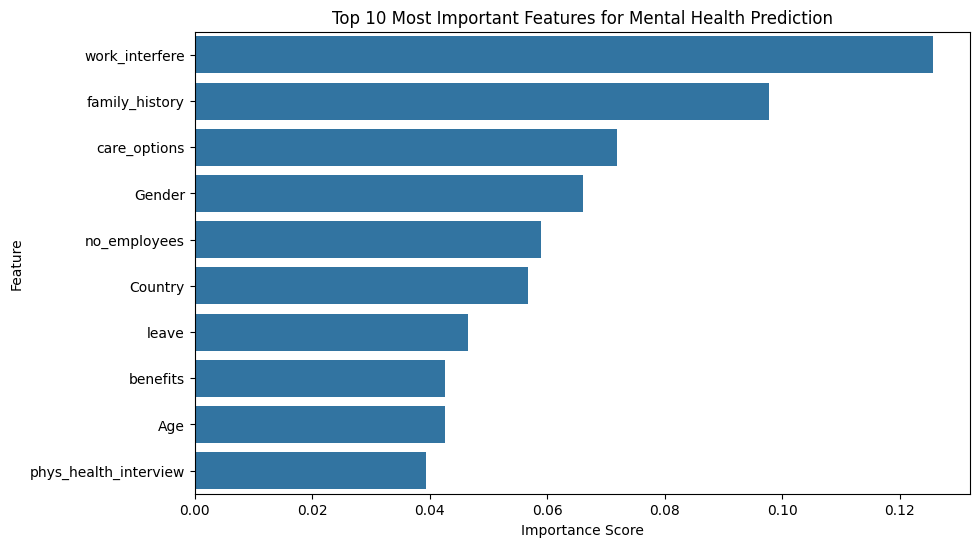

In [15]:
plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=importance_df.head(10))

plt.title("Top 10 Most Important Features for Mental Health Prediction")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.show()

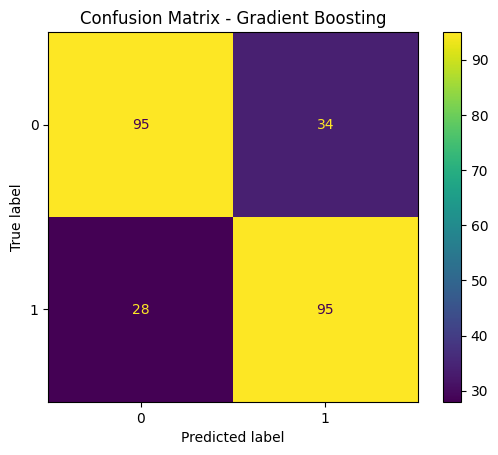

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_gb)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Gradient Boosting")
plt.show()

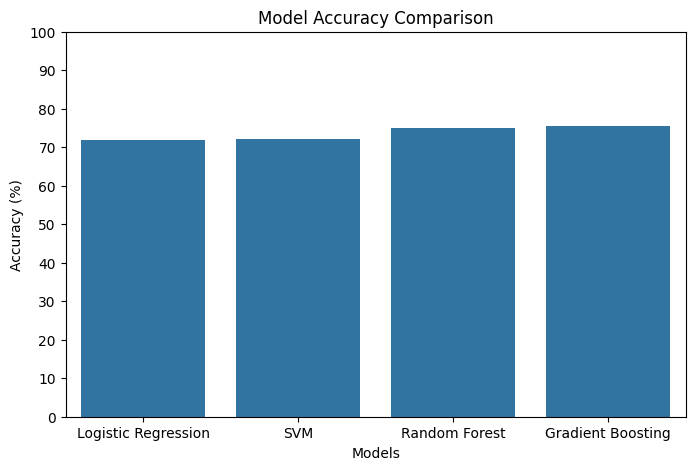

In [20]:
models = ["Logistic Regression", "SVM", "Random Forest", "Gradient Boosting"]

accuracy_scores = [
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_svm),
    accuracy_score(y_test, y_pred_rf),
    accuracy_score(y_test, y_pred_gb)
]

# Convert to percentage
accuracy_percent = [x * 100 for x in accuracy_scores]

plt.figure(figsize=(8,5))
sns.barplot(x=models, y=accuracy_percent)

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy (%)")

plt.ylim(0,100)

plt.gca().yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.show()

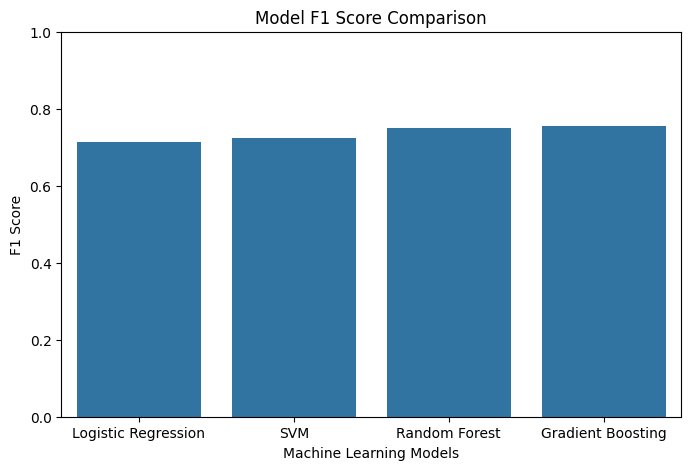

In [21]:
f1_scores = [
    f1_score(y_test, y_pred_lr),
    f1_score(y_test, y_pred_svm),
    f1_score(y_test, y_pred_rf),
    f1_score(y_test, y_pred_gb)
]

plt.figure(figsize=(8,5))
sns.barplot(x=models, y=f1_scores)

plt.title("Model F1 Score Comparison")
plt.xlabel("Machine Learning Models")
plt.ylabel("F1 Score")

plt.ylim(0,1)

plt.show()